In [2]:
import os
import numpy as np
import pandas as pd
import polars as pl  # Pour le traitement rapide des données
import matplotlib.pyplot as plt

data_dir = os.path.join("..", "..", "data", "SUPP_monomer_rate")
#scs = ['SCV', 'SCL', 'SCI', 'SCM', 'SCF', 'SCY', 'SCW']
scs = ['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT', 'SCN', 'SCQ',
       'SCF', 'SCY', 'SCW', 'SCCM', 'SCYM', 'SCE', 'SCEN', 'SCD', 'SCDN', 'SCR',
       'SCRN', 'SCK', 'SCKN', 'SCHE', 'SCHD', 'SCHP']

/Users/valentin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# =============================================================================
# MÉTHODE 1: Calcul du taux de monomères depuis extra-analysis/contacts/{sc}/batches/*.dat
# =============================================================================
# Ces fichiers contiennent déjà le % de monomères par frame (colonne monomers_%)

def calculate_monomer_rate_from_batches(sc_list, extra_analysis_dir):
    """
    Calcule le taux de monomères moyen et l'erreur standard pour chaque analogue
    depuis les fichiers batches qui contiennent déjà le % de monomères par frame.
    
    Le % est moyenné sur toutes les frames, et l'erreur standard est calculée 
    entre les 3 trajectoires.
    
    Returns:
        dict: {sc: {'mean': float, 'std': float, 'se': float, 'n_traj': int}}
    """
    results = {}
    
    for sc in sc_list:
        sc_lower = sc.lower()
        batch_dir = os.path.join(extra_analysis_dir, sc_lower, 'batches')
        
        if not os.path.exists(batch_dir):
            print(f"Répertoire non trouvé: {batch_dir}")
            continue
        
        # Collecter les moyennes de % monomères par trajectoire
        traj_means = []
        
        for traj in [1, 2, 3]:
            traj_frames_percent = []
            
            # Charger tous les batches de cette trajectoire
            batch_files = sorted([f for f in os.listdir(batch_dir) 
                                 if f.startswith(f'percent_traj{traj}_batch') and f.endswith('.dat')])
            
            for batch_file in batch_files:
                filepath = os.path.join(batch_dir, batch_file)
                try:
                    df = pl.read_csv(filepath, separator=' ', comment_prefix='#', has_header=False,
                                    new_columns=['frame', 'monomers_pct'])
                    traj_frames_percent.extend(df['monomers_pct'].to_list())
                except Exception as e:
                    print(f"Erreur lecture {filepath}: {e}")
                    continue
            
            if traj_frames_percent:
                traj_mean = np.mean(traj_frames_percent)
                traj_means.append(traj_mean)
        
        if len(traj_means) > 0:
            overall_mean = np.mean(traj_means)
            overall_std = np.std(traj_means, ddof=1) if len(traj_means) > 1 else 0
            se = overall_std / np.sqrt(len(traj_means)) if len(traj_means) > 1 else 0
            
            results[sc] = {
                'mean': overall_mean,
                'std': overall_std,
                'se': se,
                'n_traj': len(traj_means),
                'traj_means': traj_means
            }
            print(f"{sc}: {overall_mean:.2f}% ± {se:.2f}% (n={len(traj_means)} trajectoires)")
    
    return results

# Définir le chemin vers les données extra-analysis
extra_analysis_dir = os.path.join("..", "..", "data", "extra-analysis", "contacts")

# Liste des analogues disponibles
sc_list_batches = ['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT',
                'SCN', 'SCQ', 'SCF', 'SCY', 'SCW', 'SCCM', 'SCYM', 'SCD', 'SCDN', 'SCE',
                'SCEN', 'SCR', 'SCRN', 'SCK', 'SCKN', 'SCHE', 'SCHD', 'SCHP']
print("=== MÉTHODE 1: Données depuis extra-analysis/contacts/{sc}/batches/ ===\n")
monomer_rates_batches = calculate_monomer_rate_from_batches(sc_list_batches, extra_analysis_dir)

=== MÉTHODE 1: Données depuis extra-analysis/contacts/{sc}/batches/ ===

GLYD: 65.66% ± 0.17% (n=3 trajectoires)
SCP: 79.64% ± 0.35% (n=3 trajectoires)
SCA: 72.06% ± 0.45% (n=3 trajectoires)
SCV: 48.13% ± 0.51% (n=3 trajectoires)
SCL: 41.81% ± 1.07% (n=3 trajectoires)
SCI: 42.10% ± 0.24% (n=3 trajectoires)
SCC: 69.80% ± 0.56% (n=3 trajectoires)
SCM: 46.70% ± 0.43% (n=3 trajectoires)
SCS: 88.61% ± 0.09% (n=3 trajectoires)
SCT: 86.39% ± 0.06% (n=3 trajectoires)
SCN: 83.15% ± 0.25% (n=3 trajectoires)
SCQ: 80.39% ± 0.04% (n=3 trajectoires)
SCF: 47.11% ± 0.28% (n=3 trajectoires)
SCY: 48.89% ± 0.80% (n=3 trajectoires)
SCW: 43.11% ± 0.81% (n=3 trajectoires)
SCCM: 92.94% ± 0.03% (n=3 trajectoires)
SCYM: 82.67% ± 0.21% (n=3 trajectoires)
SCD: 90.53% ± 0.07% (n=3 trajectoires)
SCDN: 83.22% ± 0.19% (n=3 trajectoires)
SCE: 88.36% ± 0.02% (n=3 trajectoires)
SCEN: 72.35% ± 0.82% (n=3 trajectoires)
SCR: 76.13% ± 0.89% (n=3 trajectoires)
SCRN: 54.91% ± 0.61% (n=3 trajectoires)
SCK: 89.48% ± 0.23% (n=3

In [4]:
# =============================================================================
# MÉTHODE 2: Calcul du taux de monomères depuis SUPP_monomer_rate/{sc}/traj{t}/com*.dat
# =============================================================================
# Ces fichiers contiennent les données brutes de classification (monomer/dimer/agregat)
# On calcule: % monomer = nombre de monomères / nombre total de molécules par frame

def calculate_monomer_rate_from_com_files(sc_list, supp_dir):
    """
    Calcule le taux de monomères depuis les fichiers com_classified_*.dat
    
    Pour chaque frame:
        % monomères = (nombre de lignes avec type='monomer') / (nombre total de lignes) * 100
    
    Le % est moyenné sur toutes les frames, et l'erreur standard est calculée 
    entre les 3 trajectoires.
    
    Returns:
        dict: {sc: {'mean': float, 'std': float, 'se': float, 'n_traj': int}}
    """
    results = {}
    
    for sc in sc_list:
        sc_lower = sc.lower()
        sc_dir = os.path.join(supp_dir, sc_lower)
        
        if not os.path.exists(sc_dir):
            print(f"Répertoire non trouvé: {sc_dir}")
            continue
        
        # Collecter les moyennes de % monomères par trajectoire
        traj_means = []
        
        for traj in [1, 2, 3]:
            traj_dir = os.path.join(sc_dir, f'traj{traj}')
            
            if not os.path.exists(traj_dir):
                continue
            
            all_frames_percent = []
            
            # Charger tous les fichiers com_classified_*.dat de cette trajectoire
            com_files = sorted([f for f in os.listdir(traj_dir) 
                               if f.startswith('com_classified_') and f.endswith('.dat')])
            
            for com_file in com_files:
                filepath = os.path.join(traj_dir, com_file)
                try:
                    df = pl.read_csv(filepath, separator=' ', comment_prefix='#', has_header=False,
                                    new_columns=['frame', 'type', 'resid', 'x', 'y', 'z', 'cluster'],
                                    dtypes={
                                        'frame': pl.Int64,
                                        'type': pl.Utf8,
                                        'resid': pl.Int64,
                                        'x': pl.Float64,
                                        'y': pl.Float64,
                                        'z': pl.Float64,
                                        'cluster': pl.Utf8  # IMPORTANT: spécifier comme string
                                    }
                                    )
                    
                    # Calculer le % de monomères par frame
                    frame_stats = df.group_by('frame').agg([
                        (pl.col('type') == 'monomer').sum().alias('n_monomers'),
                        pl.count().alias('n_total')
                    ])
                    
                    frame_stats = frame_stats.with_columns([
                        (pl.col('n_monomers') / pl.col('n_total') * 100).alias('monomer_pct')
                    ])
                    
                    all_frames_percent.extend(frame_stats['monomer_pct'].to_list())
                    
                except Exception as e:
                    print(f"Erreur lecture {filepath}: {e}")
                    continue
            
            if all_frames_percent:
                traj_mean = np.mean(all_frames_percent)
                traj_means.append(traj_mean)
        
        if len(traj_means) > 0:
            overall_mean = np.mean(traj_means)
            overall_std = np.std(traj_means, ddof=1) if len(traj_means) > 1 else 0
            se = overall_std / np.sqrt(len(traj_means)) if len(traj_means) > 1 else 0
            
            results[sc] = {
                'mean': overall_mean,
                'std': overall_std,
                'se': se,
                'n_traj': len(traj_means),
                'traj_means': traj_means
            }
            print(f"{sc}: {overall_mean:.2f}% ± {se:.2f}% (n={len(traj_means)} trajectoires)")
    
    return results

# Définir le chemin vers les données SUPP_monomer_rate
supp_monomer_dir = os.path.join("..", "..", "data", "SUPP_monomer_rate")

# Liste des analogues disponibles dans SUPP_monomer_rate
#sc_list_supp = ['SCV', 'SCL', 'SCI', 'SCM', 'SCF', 'SCY', 'SCW']  # Ajuster selon les données disponibles

sc_list_supp = ['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT', 'SCN', 'SCQ',
       'SCF', 'SCY', 'SCW', 'SCCM', 'SCYM', 'SCE', 'SCEN', 'SCD', 'SCDN', 'SCR',
       'SCRN', 'SCK', 'SCKN', 'SCHE', 'SCHD', 'SCHP']
print("=== MÉTHODE 2: Données depuis SUPP_monomer_rate/{sc}/traj{t}/com*.dat ===\n")
monomer_rates_supp = calculate_monomer_rate_from_com_files(sc_list_supp, supp_monomer_dir)


# Enregistrer les résultats dans un fichier texte
# Utiliser le chemin absolu basé sur l'emplacement du notebook
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
save_file = os.path.join(notebook_dir, "..", "..", "data", "SUPP_monomer_rate", "monomer_rate.txt")
save_file = os.path.abspath(save_file)  # Convertir en chemin absolu

print(f"\n--- SAUVEGARDE DES RÉSULTATS ---")
print(f"Répertoire de travail actuel: {os.getcwd()}")
print(f"Fichier de sauvegarde: {save_file}")
print(f"Le répertoire parent existe: {os.path.exists(os.path.dirname(save_file))}")

try:
    with open(save_file, 'w') as f:
        f.write("SC\tMean_Batches\tSE_Batches\tN_Traj_Batches\n")
        for sc in sorted(set(list(monomer_rates_supp.keys()))):
            mean_supp = monomer_rates_supp.get(sc, {}).get('mean', np.nan)
            se_supp = monomer_rates_supp.get(sc, {}).get('se', np.nan)
            n_traj_supp = monomer_rates_supp.get(sc, {}).get('n_traj', 0)
            
            f.write(f"{sc}\t{mean_supp:.2f}\t{se_supp:.2f}\t{n_traj_supp}\n")
    
    # Vérifier que le fichier a bien été créé
    if os.path.exists(save_file):
        file_size = os.path.getsize(save_file)
        print(f"✓ Fichier créé avec succès: {save_file}")
        print(f"✓ Taille du fichier: {file_size} octets")
    else:
        print(f"✗ ERREUR: Le fichier n'existe pas après l'écriture!")
        
except Exception as e:
    print(f"✗ ERREUR lors de l'écriture du fichier: {e}")

=== MÉTHODE 2: Données depuis SUPP_monomer_rate/{sc}/traj{t}/com*.dat ===



/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_223/3263180816.py:48: DeprecationWarning: the argument `dtypes` for `read_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  df = pl.read_csv(filepath, separator=' ', comment_prefix='#', has_header=False,
/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_223/3263180816.py:64: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('n_total')


GLYD: 65.92% ± 0.07% (n=3 trajectoires)
SCP: 79.77% ± 0.42% (n=3 trajectoires)
SCA: 71.58% ± 0.69% (n=3 trajectoires)
SCV: 47.75% ± 0.32% (n=3 trajectoires)
SCL: 41.06% ± 0.42% (n=3 trajectoires)
SCI: 42.21% ± 0.26% (n=3 trajectoires)
SCC: 69.86% ± 0.67% (n=3 trajectoires)
SCM: 46.19% ± 0.11% (n=3 trajectoires)
SCS: 88.79% ± 0.03% (n=3 trajectoires)
SCT: 86.42% ± 0.03% (n=3 trajectoires)
SCN: 83.29% ± 0.13% (n=3 trajectoires)
SCQ: 80.62% ± 0.12% (n=3 trajectoires)
SCF: 46.75% ± 0.49% (n=3 trajectoires)
SCY: 48.51% ± 0.38% (n=3 trajectoires)
SCW: 41.92% ± 0.28% (n=3 trajectoires)
SCCM: 92.92% ± 0.02% (n=3 trajectoires)
SCYM: 83.00% ± 0.24% (n=3 trajectoires)
SCE: 88.50% ± 0.05% (n=3 trajectoires)
SCEN: 72.14% ± 0.84% (n=3 trajectoires)
SCD: 90.53% ± 0.03% (n=3 trajectoires)
SCDN: 83.39% ± 0.21% (n=3 trajectoires)
SCR: 75.87% ± 0.91% (n=3 trajectoires)
SCRN: 54.54% ± 0.40% (n=3 trajectoires)
SCK: 89.59% ± 0.24% (n=3 trajectoires)
SCKN: 72.86% ± 0.35% (n=3 trajectoires)
SCHE: 80.69% ± 0.1

=== COMPARAISON DES TAUX DE MONOMÈRES (%) ===

  SC  batches_mean  batches_se  supp_mean  supp_se
GLYD     65.658689    0.168485  65.916485 0.073656
 SCA     72.064892    0.451509  71.575579 0.691494
 SCC     69.796301    0.560281  69.864115 0.670373
SCCM     92.941294    0.025615  92.919429 0.019266
 SCD     90.529919    0.069378  90.534507 0.031934
SCDN     83.216008    0.193759  83.388071 0.209145
 SCE     88.356393    0.017948  88.496096 0.047551
SCEN     72.350100    0.818384  72.140108 0.839308
 SCF     47.114915    0.278180  46.746342 0.489056
SCHD     79.914288    0.281442  80.172704 0.183414
SCHE     80.239814    0.193635  80.685588 0.115195
SCHP     89.654230    0.148184  89.971778 0.081982
 SCI     42.101884    0.241856  42.213891 0.259214
 SCK     89.479039    0.230086  89.587909 0.244839
SCKN     72.931098    0.334285  72.858697 0.352795
 SCL     41.810444    1.066473  41.062729 0.418999
 SCM     46.701822    0.429254  46.194804 0.113262
 SCN     83.151756    0.245797  83.

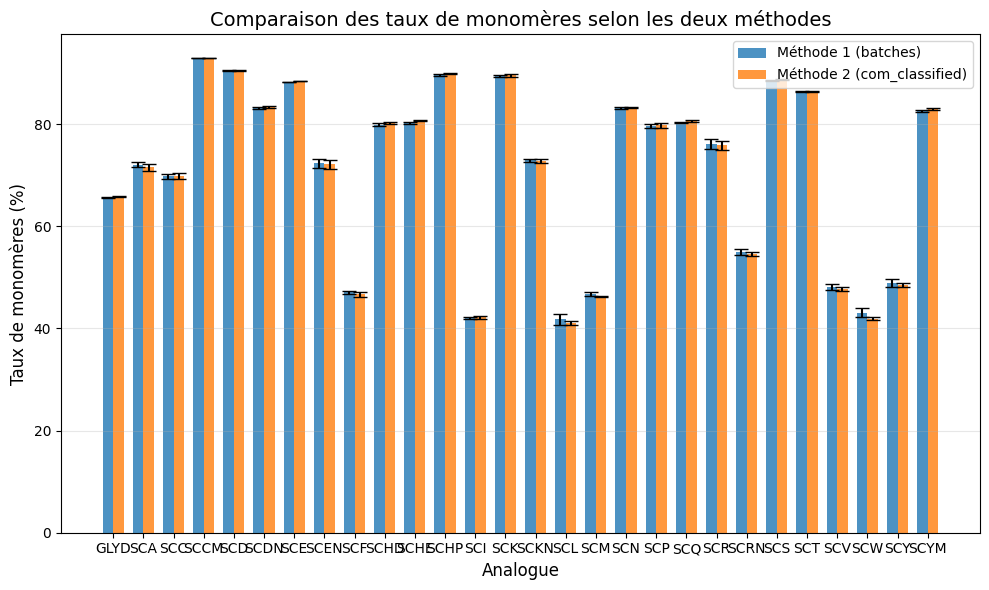

In [5]:
# =============================================================================
# COMPARAISON DES DEUX MÉTHODES
# =============================================================================

# Créer un DataFrame de comparaison
comparison_data = []

for sc in set(list(monomer_rates_batches.keys()) + list(monomer_rates_supp.keys())):
    row = {'SC': sc}
    
    if sc in monomer_rates_batches:
        row['batches_mean'] = monomer_rates_batches[sc]['mean']
        row['batches_se'] = monomer_rates_batches[sc]['se']
    else:
        row['batches_mean'] = np.nan
        row['batches_se'] = np.nan
    
    if sc in monomer_rates_supp:
        row['supp_mean'] = monomer_rates_supp[sc]['mean']
        row['supp_se'] = monomer_rates_supp[sc]['se']
    else:
        row['supp_mean'] = np.nan
        row['supp_se'] = np.nan
    
    comparison_data.append(row)

comparison_df = pl.DataFrame(comparison_data).sort('SC')

print("=== COMPARAISON DES TAUX DE MONOMÈRES (%) ===\n")
print(comparison_df.to_pandas().to_string(index=False))

# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['batches_mean'].to_list(), width, 
               yerr=comparison_df['batches_se'].to_list(), label='Méthode 1 (batches)', capsize=5, alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['supp_mean'].to_list(), width, 
               yerr=comparison_df['supp_se'].to_list(), label='Méthode 2 (com_classified)', capsize=5, alpha=0.8)

ax.set_xlabel('Analogue', fontsize=12)
ax.set_ylabel('Taux de monomères (%)', fontsize=12)
ax.set_title('Comparaison des taux de monomères selon les deux méthodes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['SC'].to_list())
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
def load_single_file(filepath):
    """
    Charge un seul fichier com_classified_*.dat avec Polars.
    """
    if not os.path.exists(filepath):
        return None
    
    # Polars est beaucoup plus rapide pour le parsing
    df = pl.read_csv(
        filepath, 
        separator=' ', 
        comment_prefix='#',
        has_header=False,
        new_columns=['frame', 'type', 'resid', 'x', 'y', 'z', 'cluster'],
        dtypes={
            'frame': pl.Int64,
            'type': pl.Utf8,
            'resid': pl.Int64,
            'x': pl.Float64,
            'y': pl.Float64,
            'z': pl.Float64,
            'cluster': pl.Utf8  # IMPORTANT: spécifier comme string
        }
    )
    return df


def compute_cluster_z_fast(df):
    """
    Calcule le z effectif de manière vectorisée avec Polars.
    - Monomère: |z| individuel
    - Dimère/Agrégat: |z moyen| du cluster
    
    BEAUCOUP plus rapide que la version itérative !
    """
    # Pour les monomères: z_eff = |z|
    # Pour les autres: z_eff = |mean(z)| du cluster dans la même frame
    
    # Créer une clé unique frame_cluster pour grouper
    df = df.with_columns([
        (pl.col('frame').cast(str) + '_' + pl.col('cluster')).alias('frame_cluster')
    ])
    
    # Calculer le z moyen par cluster par frame
    cluster_z_mean = df.group_by('frame_cluster').agg([
        pl.col('z').mean().alias('z_cluster_mean')
    ])
    
    # Joindre et calculer z_eff
    df = df.join(cluster_z_mean, on='frame_cluster', how='left')
    
    # z_eff: pour monomères = |z|, pour autres = |z_cluster_mean|
    df = df.with_columns([
        pl.when(pl.col('type') == 'monomer')
        .then(pl.col('z').abs())
        .otherwise(pl.col('z_cluster_mean').abs())
        .alias('z_eff')
    ])
    
    return df.drop(['frame_cluster', 'z_cluster_mean'])


def compute_fractions_single_file(filepath, z_bins):
    """
    Traite un seul fichier et retourne les fractions par bin de z.
    
    IMPORTANT: Chaque ligne du fichier = 1 résidu à 1 frame donnée.
    Les pourcentages représentent donc bien:
        % monomères = nombre de résidus isolés / nombre total de résidus
        % dimères = nombre de résidus en dimère / nombre total de résidus
        % agrégats = nombre de résidus en agrégat / nombre total de résidus
    """
    df = load_single_file(filepath)
    if df is None or df.height == 0:
        return None
    
    # Calculer z_eff
    df = compute_cluster_z_fast(df)
    
    # Binning avec Polars
    bin_width = z_bins[1] - z_bins[0]
    z_min = z_bins[0]
    
    df = df.with_columns([
        ((pl.col('z_eff') - z_min) / bin_width).floor().cast(pl.Int32).alias('z_bin')
    ])
    
    # Filtrer les bins valides
    n_bins = len(z_bins) - 1
    df = df.filter((pl.col('z_bin') >= 0) & (pl.col('z_bin') < n_bins))
    
    # Compter le nombre de résidus par bin et par type
    # Note: pl.count() compte les lignes = nombre de résidus (1 ligne = 1 résidu)
    counts = df.group_by(['z_bin', 'type']).agg([
        pl.count().alias('count')  # Nombre de résidus de ce type dans ce bin
    ]).pivot(
        on='type',
        index='z_bin',
        values='count'
    ).fill_null(0)
    
    #display(counts)

    # S'assurer que toutes les colonnes existent
    for col in ['monomer', 'dimer', 'agregat']:
        if col not in counts.columns:
            counts = counts.with_columns(pl.lit(0).alias(col))
    
    # Calculer le nombre total de résidus par bin
    counts = counts.with_columns([
        (pl.col('monomer') + pl.col('dimer') + pl.col('agregat')).alias('total')
    ])
    
    # Calculer les fractions (nombre de résidus de ce type / nombre total de résidus)
    counts = counts.with_columns([
        (pl.col('monomer') / pl.col('total')).alias('frac_monomer'),
        (pl.col('dimer') / pl.col('total')).alias('frac_dimer'),
        (pl.col('agregat') / pl.col('total')).alias('frac_agregat'),
        (pl.col('z_bin') * bin_width + z_min + bin_width / 2).alias('z_center')
    ])
    
    return counts.select([
        'z_bin', 'z_center', 'monomer', 'dimer', 'agregat', 
        'total', 'frac_monomer', 'frac_dimer', 'frac_agregat'
    ])


def load_trajectory_data_fast(sc, traj_idx, data_dir, z_bins):
    """
    Charge et traite les 3 batches d'une trajectoire avec Polars.
    Retourne directement les fractions agrégées.
    
    Les fractions sont recalculées après agrégation des batches pour 
    garantir: % = nombre total de résidus de ce type / nombre total de résidus
    """
    all_counts = []
    
    for batch in range(1, 4):
        filepath = os.path.join(data_dir, sc.lower(), f'traj{traj_idx}', f'com_classified_{batch}.dat')
        
        counts = compute_fractions_single_file(filepath, z_bins)
        if counts is not None:
            all_counts.append(counts)
    
    if len(all_counts) == 0:
        return None
    
    # Concaténer tous les batches
    combined = pl.concat(all_counts)
    
    # Agréger par z_bin (somme des counts = somme du nombre de résidus)
    result = combined.group_by('z_bin').agg([
        pl.col('monomer').sum(),
        pl.col('dimer').sum(),
        pl.col('agregat').sum(),
        pl.col('total').sum(),
        pl.col('z_center').first()
    ])
    
    # Recalculer les fractions sur les totaux agrégés
    # Garantit: % = nombre de résidus de ce type / nombre total de résidus (sur tous les batches)
    result = result.with_columns([
        (pl.col('monomer') / pl.col('total')).alias('frac_monomer'),
        (pl.col('dimer') / pl.col('total')).alias('frac_dimer'),
        (pl.col('agregat') / pl.col('total')).alias('frac_agregat')
    ])
    
    return result.sort('z_bin')

In [7]:
def analyze_analog_fast(sc, data_dir, z_bins):
    """
    Analyse complète d'un analogue sur ses 3 trajectoires avec Polars.
    
    Returns:
    --------
    DataFrame Pandas avec moyennes et erreurs standards par bin de z
    """
    trajs = [1, 2, 3]
    traj_results = []
    
    for traj_idx in trajs:
        print(f"  Traitement {sc} traj{traj_idx}...", end=' ')
        
        result = load_trajectory_data_fast(sc, traj_idx, data_dir, z_bins)
        if result is None or result.height == 0:
            print("Pas de données")
            continue
        
        result = result.with_columns(pl.lit(traj_idx).alias('traj'))
        traj_results.append(result)
        print(f"OK ({result.height} bins)")
    
    if len(traj_results) == 0:
        return None
    
    # Fusionner les trajectoires
    all_data = pl.concat(traj_results)
    
    # Calculer moyenne et std par z_center
    summary = all_data.group_by('z_center').agg([
        pl.col('total').mean().alias('total_mean'),
        pl.col('frac_monomer').mean().alias('mono_mean'),
        pl.col('frac_monomer').std().alias('mono_std'),
        pl.col('frac_monomer').count().alias('mono_n'),
        pl.col('frac_dimer').mean().alias('dimer_mean'),
        pl.col('frac_dimer').std().alias('dimer_std'),
        pl.col('frac_dimer').count().alias('dimer_n'),
        pl.col('frac_agregat').mean().alias('agreg_mean'),
        pl.col('frac_agregat').std().alias('agreg_std'),
        pl.col('frac_agregat').count().alias('agreg_n'),
    ]).sort('z_center')
    
    # Calculer les erreurs standards
    summary = summary.with_columns([
        (pl.col('mono_std') / pl.col('mono_n').sqrt()).alias('mono_se'),
        (pl.col('dimer_std') / pl.col('dimer_n').sqrt()).alias('dimer_se'),
        (pl.col('agreg_std') / pl.col('agreg_n').sqrt()).alias('agreg_se'),
    ])
    
    # RETOURNER POLARS (pas de conversion)
    return summary

In [8]:
# Analyser tous les analogues avec Polars (BEAUCOUP plus rapide!)
import pickle
import time

results = {}
z_bins = np.arange(0, 50, 1)  # Bins de 0 à 50 Å avec un pas de 1 Å

# Fichier de sauvegarde
save_file = os.path.join(data_dir, 'analysis_results_polars.pkl')

# Option: forcer le recalcul même si le fichier existe
FORCE_RECALCULATE = False

if os.path.exists(save_file) and not FORCE_RECALCULATE:
    print(f"Chargement des résultats depuis {save_file}...")
    with open(save_file, 'rb') as f:
        results = pickle.load(f)
    print(f"{len(results)} analogues chargés: {list(results.keys())}")
else:
    print("Calcul des résultats avec Polars (version optimisée)...")
    start_time = time.time()
    
    for sc in scs:
        print(f"\n=== Analyse de {sc} ===")
        sc_start = time.time()
        
        summary = analyze_analog_fast(sc, data_dir, z_bins)
        
        if summary is not None:
            results[sc] = summary
            print(f"  Terminé en {time.time() - sc_start:.1f}s")
    
    total_time = time.time() - start_time
    print(f"\n Temps total: {total_time:.1f}s")
    
    # Sauvegarder les résultats
    print(f"Sauvegarde des résultats dans {save_file}...")
    with open(save_file, 'wb') as f:
        pickle.dump(results, f)
    print("Sauvegarde terminée!")

print(f"\n{len(results)} analogues disponibles")

Chargement des résultats depuis ../../data/SUPP_monomer_rate/analysis_results_polars.pkl...
28 analogues chargés: ['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT', 'SCN', 'SCQ', 'SCF', 'SCY', 'SCW', 'SCCM', 'SCYM', 'SCE', 'SCEN', 'SCD', 'SCDN', 'SCR', 'SCRN', 'SCK', 'SCKN', 'SCHE', 'SCHD', 'SCHP']

28 analogues disponibles


In [9]:
# Optionnel: Sauvegarder aussi en CSV pour chaque analogue (plus lisible)
csv_dir = os.path.join(data_dir, 'analysis_csv')
os.makedirs(csv_dir, exist_ok=True)

for sc, summary in results.items():
    csv_file = os.path.join(csv_dir, f'{sc}_summary.csv')
    summary.write_csv(csv_file)
    print(f"Sauvegardé: {csv_file}")

print(f"\nFichiers CSV sauvegardés dans {csv_dir}")

Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/GLYD_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCP_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCA_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCV_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCL_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCI_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCC_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCM_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCS_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCT_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCN_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCQ_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCF_summary.csv
Sauvegardé: ../../data/SUPP_monomer_rate/analysis_csv/SCY_summary.csv
Sauvegardé: ../../d

In [24]:
def plot_stacked_fractions(summary, sc, ax=None):
    """
    Crée un graphique empilé des fractions de monomères, dimères et agrégats.
    
    L'aire totale représente la densité relative (normalisée) et est divisée
    en 3 zones selon le type d'interaction.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    z = summary['z_center'].to_numpy()
    
    # Fractions (en pourcentage)
    mono = summary['mono_mean'].to_numpy() * 100
    dimer = summary['dimer_mean'].to_numpy() * 100
    agreg = summary['agreg_mean'].to_numpy() * 100
    
    # Remplacer NaN par 0
    mono = np.nan_to_num(mono, 0)
    dimer = np.nan_to_num(dimer, 0)
    agreg = np.nan_to_num(agreg, 0)
    
    # Graphique empilé
    ax.fill_between(z, 0, mono, alpha=0.7, label='Monomer', color='#2ecc71')
    ax.fill_between(z, mono, mono + dimer, alpha=0.7, label='Dimer', color='#3498db')
    ax.fill_between(z, mono + dimer, mono + dimer + agreg, alpha=0.7, label='Aggregate', color='#e74c3c')

    # Lignes de contour
    ax.plot(z, mono, color='#27ae60', linewidth=1)
    ax.plot(z, mono + dimer, color='#2980b9', linewidth=1)
    ax.plot(z, mono + dimer + agreg, color='#c0392b', linewidth=1)
    
    ax.set_xlabel('z (Å)', fontsize=12)
    ax.set_ylabel('Purcentage (%)', fontsize=12)
    ax.set_title(f'{sc}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 45])
    ax.set_ylim([0, 100])
    ax.legend(loc='lower right', fontsize=12)
    
    # Grille verticale pour les zones membranaires
    for xv in [9.5, 19.5, 30]:
        ax.axvline(x=xv, linestyle='--', alpha=0.5, linewidth=0.8, color='gray')
    
    return ax

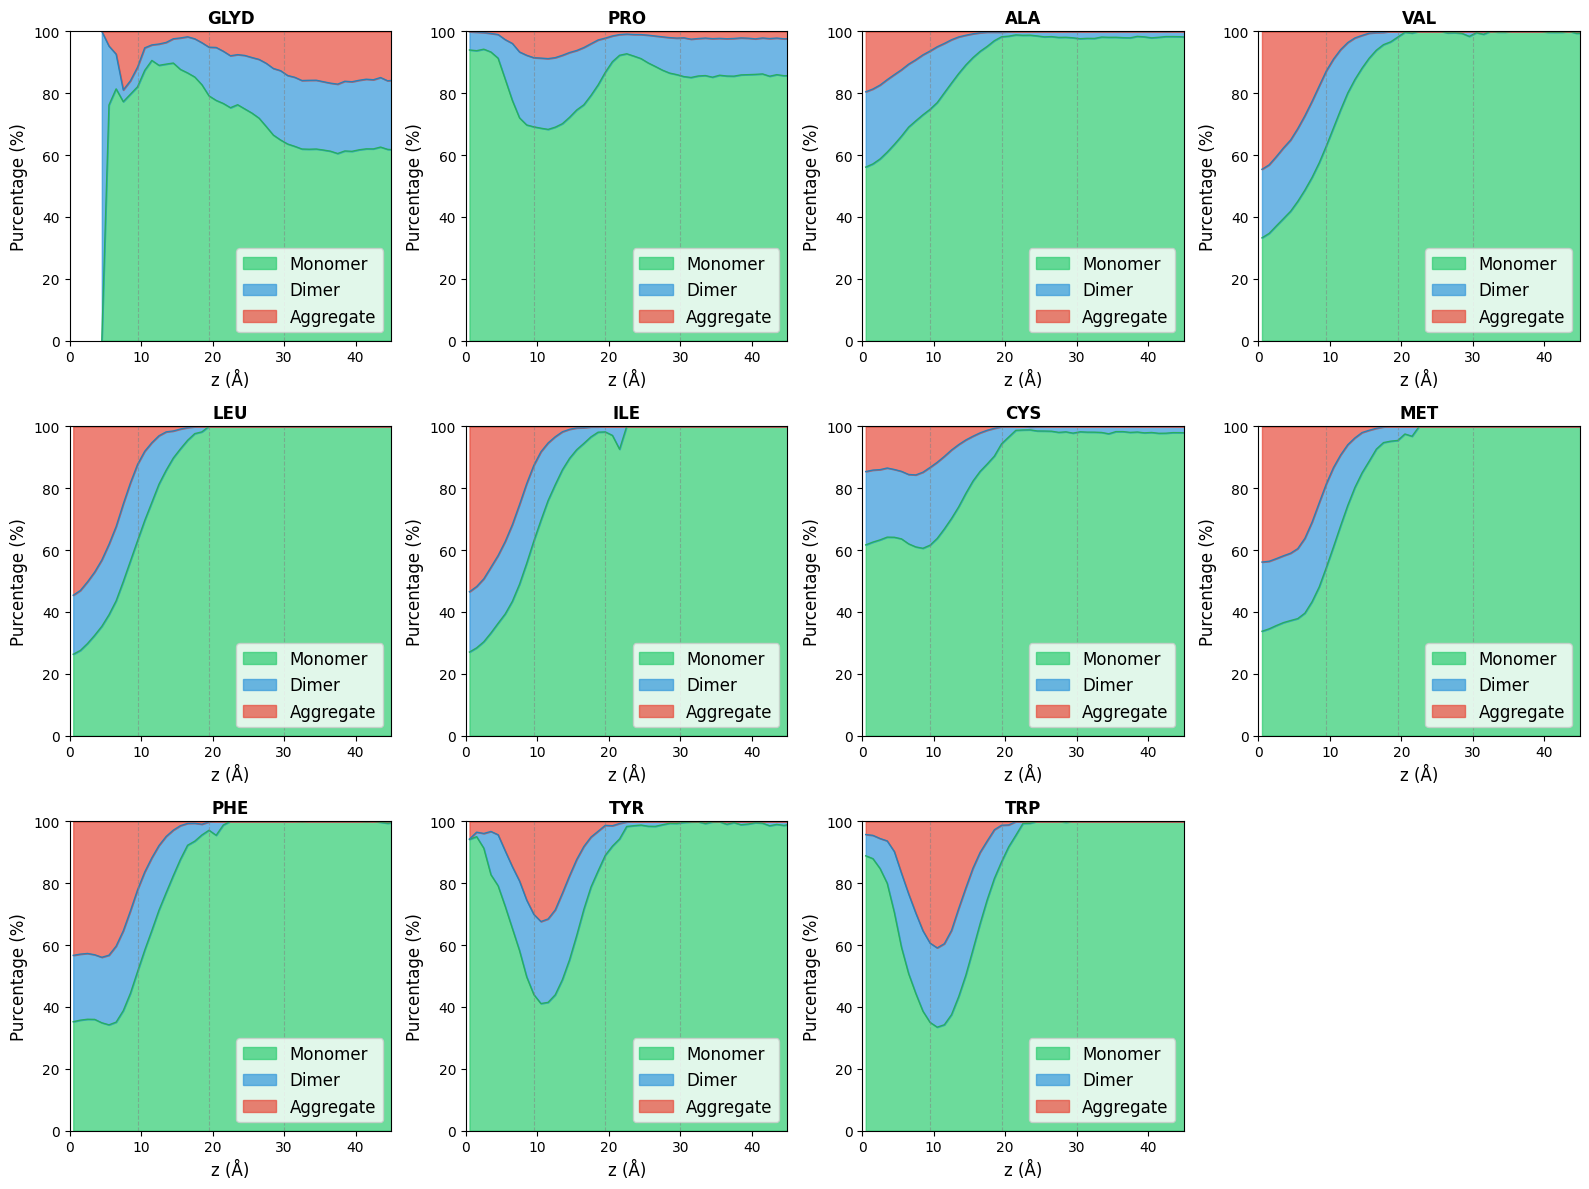

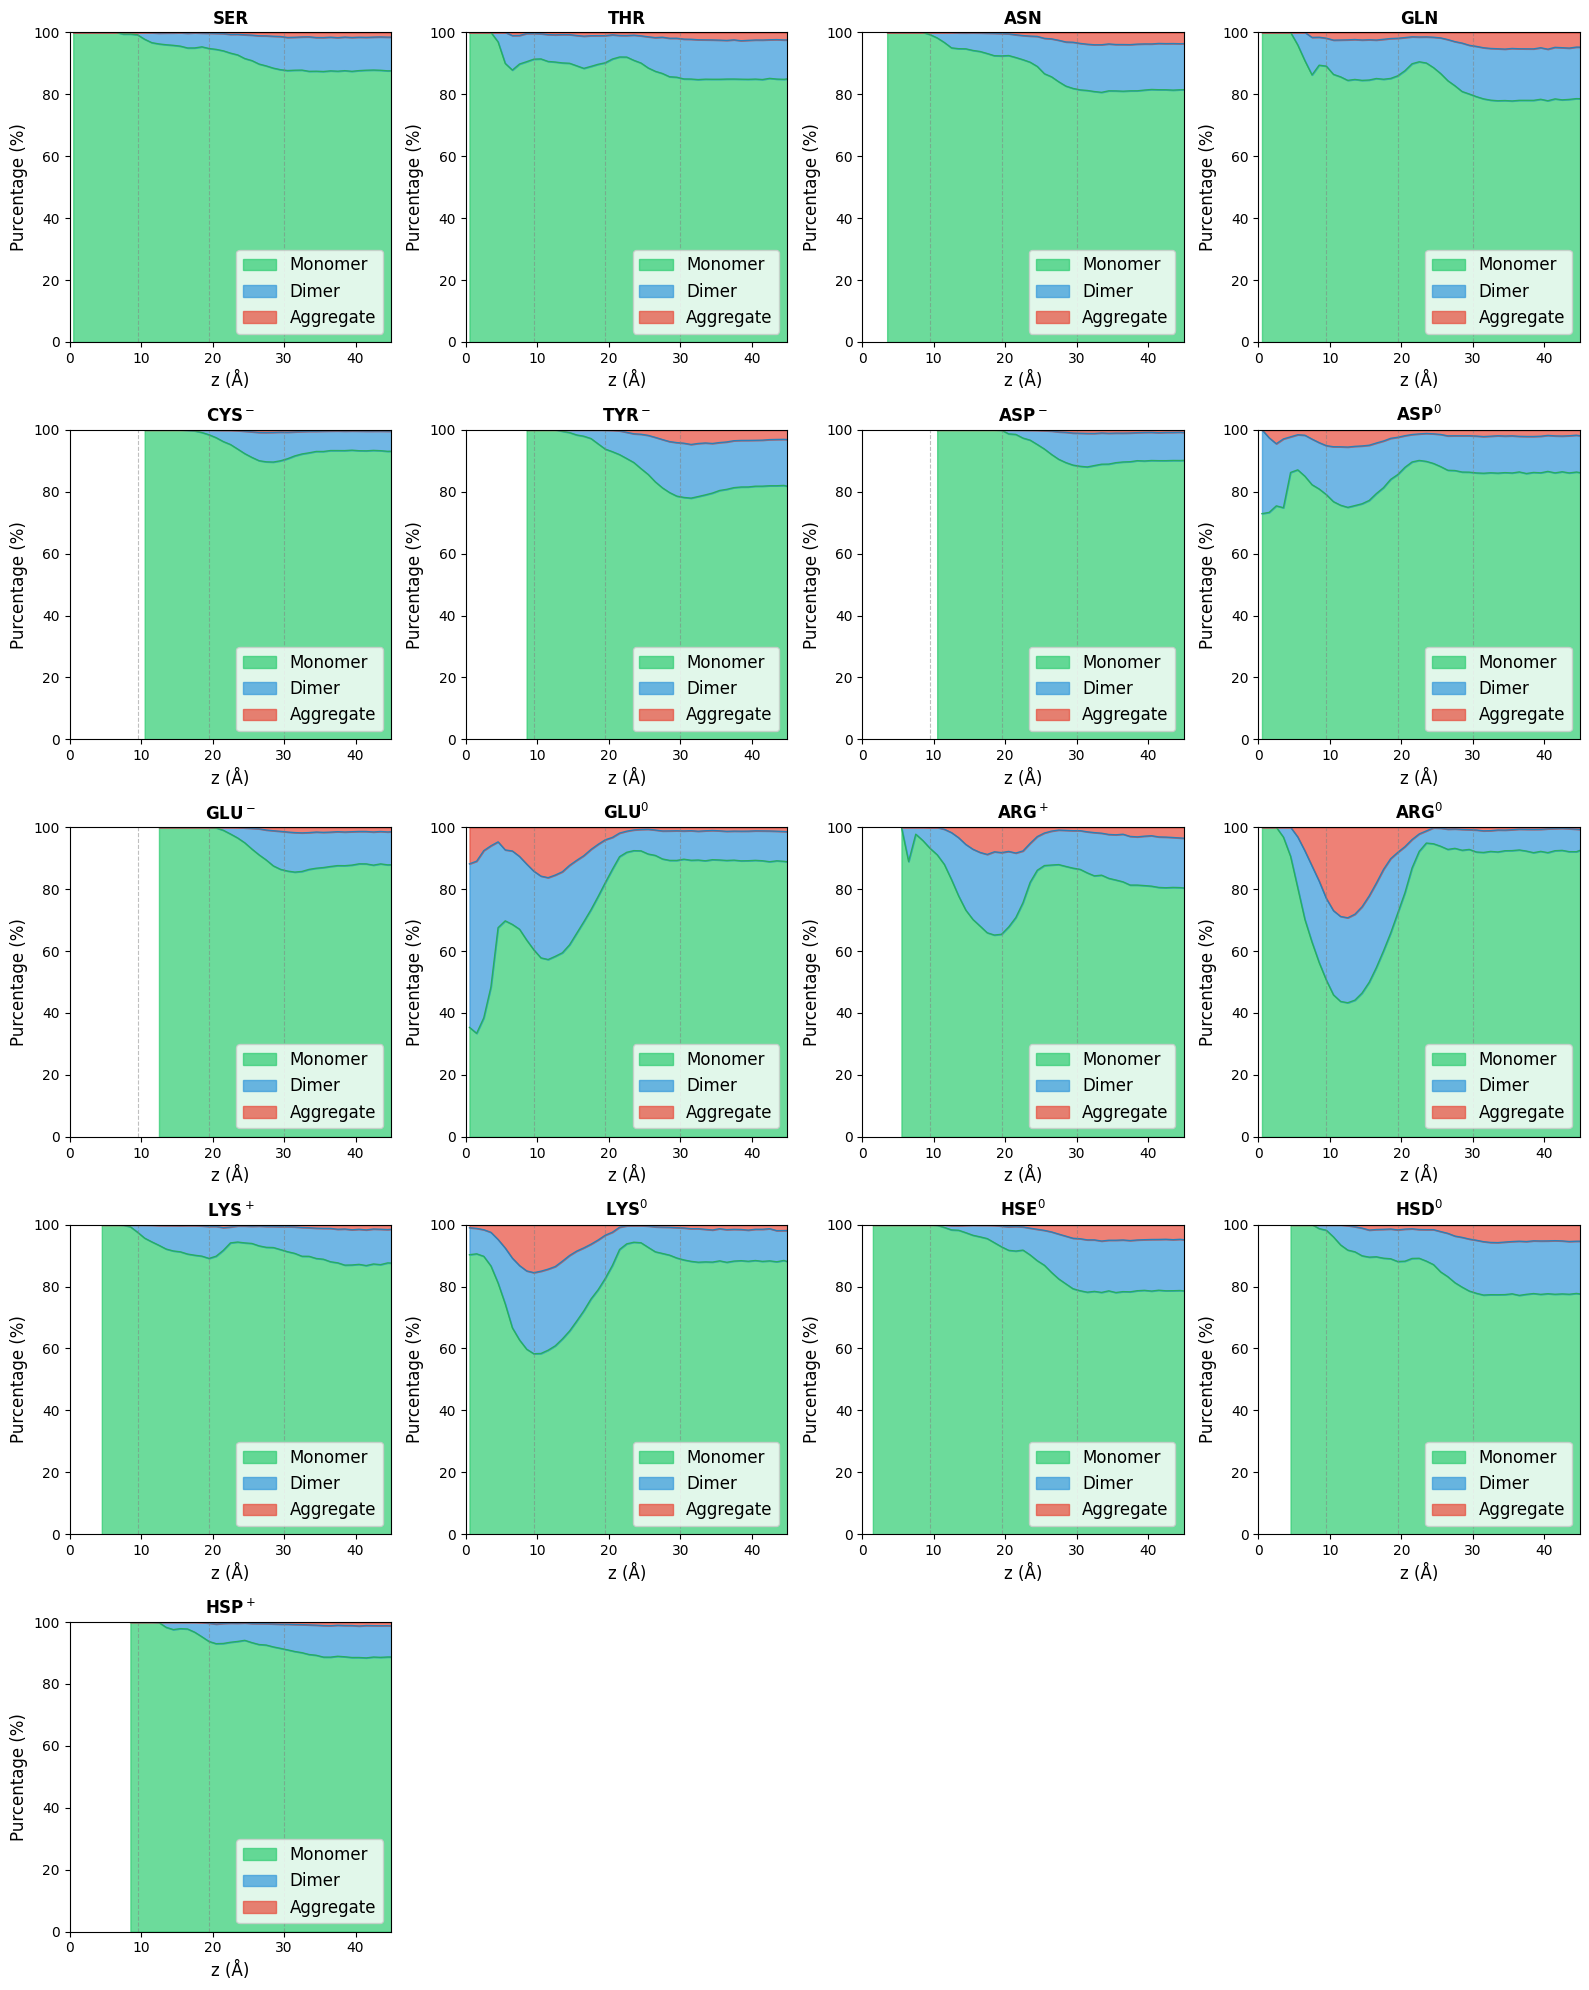

In [25]:
def plot_all_analogs(results, sidechain, label, name='all'):
    """
    Crée un graphique empilé pour chaque analogue de la liste sidechain.
    """
    # Plot pour chaque analogue
    n_analogs = len(sidechain)
    n_cols = 4
    n_rows = int(np.ceil(n_analogs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    # Parcourir sidechain plutôt que results
    for i, sc in enumerate(sidechain):
        if sc in results:
            summary = results[sc]
            plot_stacked_fractions(summary, label[i], ax=axes[i])
        else:
            # Si l'analogue n'est pas dans results, masquer l'axe
            axes[i].set_visible(False)
    
    # Masquer les axes inutilisés (s'il y a moins d'analogues que d'axes)
    for j in range(len(sidechain), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'../../plot/monomer_rate_{name}.png', dpi=600, bbox_inches='tight')
    plt.show()
s = ['GLYD', 'SCP', 'SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCF', 'SCY', 'SCW']
l = ['GLYD', 'PRO', 'ALA', 'VAL', 'LEU', 'ILE', 'CYS', 'MET', 'PHE', 'TYR', 'TRP']
plot_all_analogs(results, s, l, name='hydrophobic')

s = ['SCS', 'SCT', 'SCN', 'SCQ', 'SCCM', 'SCYM', 'SCD', 'SCDN', 'SCE', 'SCEN', 'SCR', 'SCRN', 'SCK', 'SCKN', 'SCHE', 'SCHD', 'SCHP']
l = ['SER', 'THR', 'ASN', 'GLN', 'CYS$^-$', 'TYR$^-$', 'ASP$^-$', 'ASP$^0$', 'GLU$^-$', 'GLU$^0$', 'ARG$^+$',
       'ARG$^0$', 'LYS$^+$', 'LYS$^0$', 'HSE$^0$', 'HSD$^0$', 'HSP$^+$']
plot_all_analogs(results, s, l, name='polar')

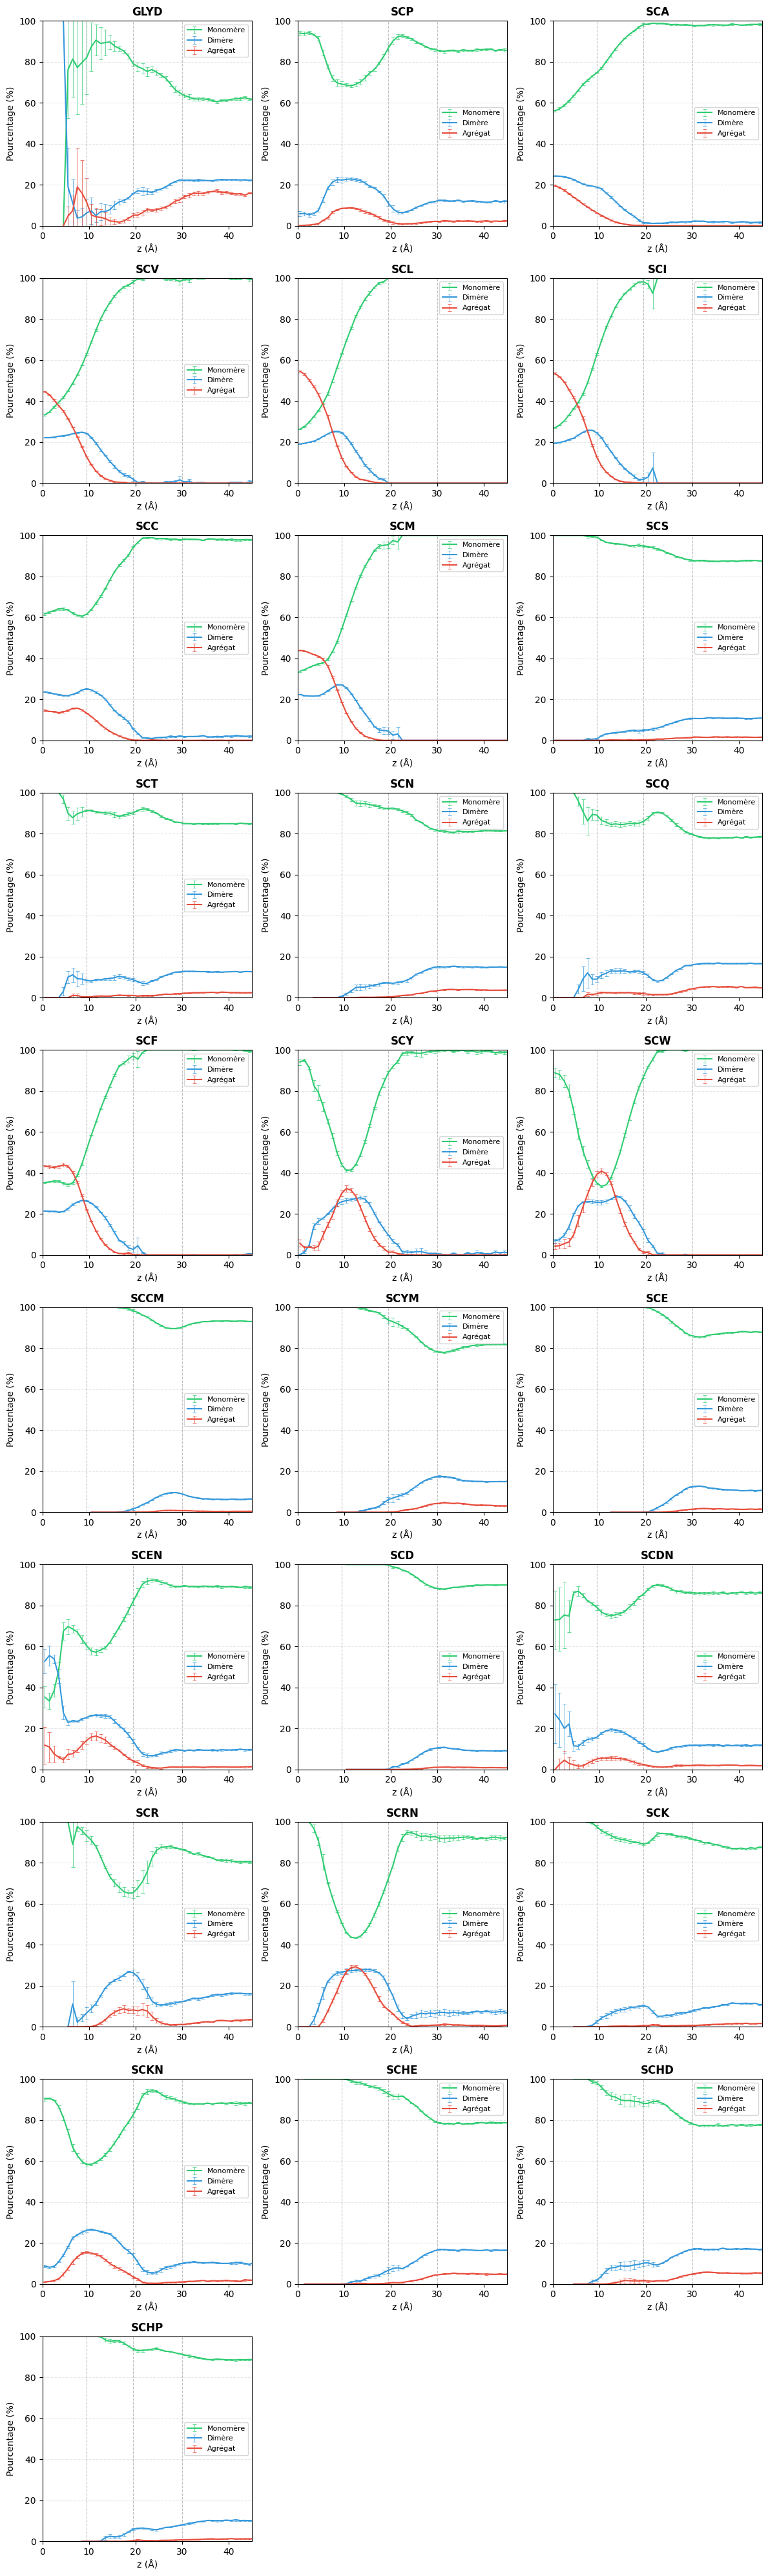

In [ ]:
def plot_with_errorbars(summary, sc, ax=None):
    """
    Crée un graphique avec barres d'erreur pour les fractions.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    z = summary['z_center'].to_numpy()
    
    # Fractions (en pourcentage)
    mono = summary['mono_mean'].to_numpy() * 100
    dimer = summary['dimer_mean'].to_numpy() * 100
    agreg = summary['agreg_mean'].to_numpy() * 100
    
    # Erreurs standards (en pourcentage)
    mono_se = summary['mono_se'].to_numpy() * 100
    dimer_se = summary['dimer_se'].to_numpy() * 100
    agreg_se = summary['agreg_se'].to_numpy() * 100
    
    # Remplacer NaN par 0
    mono = np.nan_to_num(mono, 0)
    dimer = np.nan_to_num(dimer, 0)
    agreg = np.nan_to_num(agreg, 0)
    mono_se = np.nan_to_num(mono_se, 0)
    dimer_se = np.nan_to_num(dimer_se, 0)
    agreg_se = np.nan_to_num(agreg_se, 0)
    
    # Plot avec barres d'erreur
    ax.errorbar(z, mono, yerr=mono_se, label='Monomère', color='#2ecc71', 
                linewidth=1.5, capsize=2, capthick=0.5, elinewidth=0.5)
    ax.errorbar(z, dimer, yerr=dimer_se, label='Dimère', color='#3498db',
                linewidth=1.5, capsize=2, capthick=0.5, elinewidth=0.5)
    ax.errorbar(z, agreg, yerr=agreg_se, label='Agrégat', color='#e74c3c',
                linewidth=1.5, capsize=2, capthick=0.5, elinewidth=0.5)
    
    ax.set_xlabel('z (Å)', fontsize=10)
    ax.set_ylabel('Pourcentage (%)', fontsize=10)
    ax.set_title(f'{sc}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 45])
    ax.set_ylim([0, 100])
    ax.legend(loc='best', fontsize=8)
    
    # Grille verticale pour les zones membranaires
    for xv in [9.5, 19.5, 30]:
        ax.axvline(x=xv, linestyle='--', alpha=0.5, linewidth=0.8, color='gray')
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    return ax


# Plot avec barres d'erreur pour chaque analogue
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, (sc, summary) in enumerate(results.items()):
    plot_with_errorbars(summary, sc, ax=axes[i])

# Masquer les axes inutilisés
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../../plot/monomer_rate_errorbars.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# Statistiques globales (tout z confondu)
# ============================================================================

def compute_global_stats(sc, data_dir):
    """
    Calcule les pourcentages globaux en sommant tous les résidus sur 
    toutes les trajectoires et tous les bins de z.
    
    Retourne le vrai pourcentage: n_résidus_type / n_résidus_total
    """
    all_counts = {'monomer': 0, 'dimer': 0, 'agregat': 0, 'total': 0}
    
    for traj in [1, 2, 3]:
        for batch in [1, 2, 3]:
            filepath = os.path.join(data_dir, sc.lower(), f'traj{traj}', f'com_classified_{batch}.dat')
            df = load_single_file(filepath)
            
            if df is None:
                continue
            
            # Compter par type
            type_counts = df.group_by('type').agg(pl.count().alias('n'))
            
            # Additionner aux totaux
            for row in type_counts.iter_rows(named=True):
                all_counts[row['type']] += row['n']
                all_counts['total'] += row['n']
    
    # Calculer les pourcentages
    if all_counts['total'] == 0:
        return None
    
    return {
        'monomer': all_counts['monomer'] / all_counts['total'] * 100,
        'dimer': all_counts['dimer'] / all_counts['total'] * 100,
        'agregat': all_counts['agregat'] / all_counts['total'] * 100,
        'total_residues': all_counts['total']
    }


print("=" * 80)
print("STATISTIQUES GLOBALES (tout z confondu, toutes trajectoires)")
print("Pourcentage = nombre de résidus de type t / nombre total de résidus")
print("=" * 80)

for sc in scs:
    stats = compute_global_stats(sc, data_dir)
    
    if stats:
        print(f"\n{sc}: ({stats['total_residues']:,} résidus × frames au total)")
        print(f"  Monomère: {stats['monomer']:5.2f}%")
        print(f"  Dimère:   {stats['dimer']:5.2f}%")
        print(f"  Agrégat:  {stats['agregat']:5.2f}%")
        print(f"  Total:    {stats['monomer'] + stats['dimer'] + stats['agregat']:5.2f}%")

#print("\n" + "=" * 80)
#print("COMPARAISON: Moyenne pondérée des bins de z (méthode précédente)")
#print("=" * 80)

#for sc, summary in results.items():
#    # Moyenne pondérée par le nombre total (ANCIENNE MÉTHODE - pour comparaison)
#    weights = summary['total_mean'].to_numpy()
#    weights = np.nan_to_num(weights.copy(), 0)
#    
#    if weights.sum() > 0:
#        mono_avg = np.average(np.nan_to_num(summary['mono_mean'].to_numpy().copy(), 0), weights=weights) * 100
#        dimer_avg = np.average(np.nan_to_num(summary['dimer_mean'].to_numpy().copy(), 0), weights=weights) * 100
#        agreg_avg = np.average(np.nan_to_num(summary['agreg_mean'].to_numpy().copy(), 0), weights=weights) * 100
#        
#        print(f"\n{sc} (moyenne pondérée par bins):")
#        print(f"  Monomère: {mono_avg:5.2f}%")
#        print(f"  Dimère:   {dimer_avg:5.2f}%")
#        print(f"  Agrégat:  {agreg_avg:5.2f}%")

STATISTIQUES GLOBALES (tout z confondu, toutes trajectoires)
Pourcentage = nombre de résidus de type t / nombre total de résidus


/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_65667/185177252.py:9: DeprecationWarning: the argument `dtypes` for `read_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  df = pl.read_csv(
/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_65667/2233706379.py:23: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  type_counts = df.group_by('type').agg(pl.count().alias('n'))



GLYD: (4,687,800 résidus × frames au total)
  Monomère: 65.92%
  Dimère:   20.70%
  Agrégat:  13.38%
  Total:    100.00%

SCP: (4,687,800 résidus × frames au total)
  Monomère: 79.77%
  Dimère:   15.74%
  Agrégat:   4.48%
  Total:    100.00%

SCA: (4,687,800 résidus × frames au total)
  Monomère: 71.58%
  Dimère:   17.89%
  Agrégat:  10.53%
  Total:    100.00%

SCV: (4,687,800 résidus × frames au total)
  Monomère: 47.75%
  Dimère:   21.90%
  Agrégat:  30.35%
  Total:    100.00%

SCL: (4,686,968 résidus × frames au total)
  Monomère: 41.06%
  Dimère:   20.42%
  Agrégat:  38.52%
  Total:    100.00%

SCI: (4,685,226 résidus × frames au total)
  Monomère: 42.21%
  Dimère:   20.91%
  Agrégat:  36.88%
  Total:    100.00%

SCC: (4,687,800 résidus × frames au total)
  Monomère: 69.86%
  Dimère:   19.86%
  Agrégat:  10.28%
  Total:    100.00%

SCM: (4,687,800 résidus × frames au total)
  Monomère: 46.19%
  Dimère:   22.49%
  Agrégat:  31.31%
  Total:    100.00%

SCS: (4,685,720 résidus × fram

In [ ]:
# =============================================================================
# DURÉE DES CONTACTS (DIMÈRES ET AGRÉGATS)
# =============================================================================
# But: Calculer combien de frames consécutives une paire de résidus reste en contact
# IMPORTANT: Un contact dimère qui devient agrégat continue d'être compté !
# Conversion: 1 frame = 10 ps

from itertools import combinations

def extract_contact_pairs_from_file(filepath):
    """
    Extrait TOUTES les paires de résidus en contact pour chaque frame.
    
    - Pour les dimères (2 résidus): 1 paire
    - Pour les agrégats (N résidus): toutes les combinaisons de 2 parmi N
    
    Ainsi, si un dimère A-B devient un agrégat A-B-C, le contact A-B 
    continue d'être suivi.
    
    Returns:
        dict: {frame: set of frozenset pairs}
    """
    df = load_single_file(filepath)
    if df is None:
        return {}
    
    # Filtrer dimères ET agrégats (exclure monomères)
    contacts = df.filter(pl.col('type').is_in(['dimer', 'agregat']))
    
    if contacts.height == 0:
        return {}
    
    # Extraire les paires depuis le cluster ID
    frame_pairs = {}
    
    for row in contacts.iter_rows(named=True):
        frame = row['frame']
        cluster = row['cluster']
        
        # Parser le cluster pour obtenir tous les resids
        resids = [int(r) for r in cluster.split('_')]
        
        if frame not in frame_pairs:
            frame_pairs[frame] = set()
        
        # Pour un dimère: 1 paire
        # Pour un agrégat de N résidus: toutes les combinaisons C(N,2)
        if len(resids) >= 2:
            for pair in combinations(resids, 2):
                frame_pairs[frame].add(frozenset(pair))
    
    return frame_pairs


def compute_contact_durations(sc, traj, data_dir):
    """
    Calcule la durée de chaque contact entre paires de résidus pour une trajectoire.
    
    Inclut les contacts dans les dimères ET les agrégats.
    Un contact A-B qui passe de dimère à agrégat continue d'être suivi.
    
    Returns:
        list: Liste des durées en frames pour chaque événement de contact
    """
    # Charger les 3 batches et fusionner
    all_frame_pairs = {}
    
    for batch in [1, 2, 3]:
        filepath = os.path.join(data_dir, sc.lower(), f'traj{traj}', f'com_classified_{batch}.dat')
        batch_pairs = extract_contact_pairs_from_file(filepath)
        
        for frame, pairs in batch_pairs.items():
            if frame not in all_frame_pairs:
                all_frame_pairs[frame] = set()
            all_frame_pairs[frame].update(pairs)
    
    if not all_frame_pairs:
        return []
    
    # Trier les frames
    sorted_frames = sorted(all_frame_pairs.keys())
    
    # Suivre les contacts actifs: {pair: start_frame}
    active_contacts = {}
    contact_durations = []
    
    for i, frame in enumerate(sorted_frames):
        current_pairs = all_frame_pairs[frame]
        
        # Vérifier si c'est une frame consécutive
        is_consecutive = (i > 0 and frame == sorted_frames[i-1] + 1)
        
        if not is_consecutive:
            # Nouvelle séquence: terminer tous les contacts actifs
            for pair, start in active_contacts.items():
                duration = sorted_frames[i-1] - start + 1 if i > 0 else 1
                contact_durations.append(duration)
            active_contacts = {}
        
        # Terminer les contacts qui ne sont plus actifs
        pairs_to_remove = []
        for pair in active_contacts:
            if pair not in current_pairs:
                duration = sorted_frames[i-1] - active_contacts[pair] + 1
                contact_durations.append(duration)
                pairs_to_remove.append(pair)
        
        for pair in pairs_to_remove:
            del active_contacts[pair]
        
        # Démarrer les nouveaux contacts
        for pair in current_pairs:
            if pair not in active_contacts:
                active_contacts[pair] = frame
    
    # Terminer les contacts encore actifs à la fin
    if sorted_frames:
        for pair, start in active_contacts.items():
            duration = sorted_frames[-1] - start + 1
            contact_durations.append(duration)
    
    return contact_durations


def analyze_contact_durations(sc_list, data_dir):
    """
    Analyse les durées de contacts (dimères + agrégats) pour tous les analogues.
    
    Returns:
        DataFrame avec statistiques par analogue
    """
    results = []
    
    for sc in sc_list:
        print(f"\nAnalyse {sc}...")
        all_durations = []
        
        for traj in [1, 2, 3]:
            durations = compute_contact_durations(sc, traj, data_dir)
            all_durations.extend(durations)
            print(f"  Traj{traj}: {len(durations)} événements de contact")
        
        if all_durations:
            durations_array = np.array(all_durations)
            
            # Statistiques en frames
            mean_frames = np.mean(durations_array)
            std_frames = np.std(durations_array)
            median_frames = np.median(durations_array)
            max_frames = np.max(durations_array)
            min_frames = np.min(durations_array)
            
            # Conversion en temps (1 frame = 10 ps)
            mean_ps = mean_frames * 10
            std_ps = std_frames * 10
            median_ps = median_frames * 10
            max_ps = max_frames * 10
            min_ps = min_frames * 10
            
            # Conversion en ns pour lisibilité
            mean_ns = mean_ps / 1000
            max_ns = max_ps / 1000
            median_ns = median_ps / 1000
            
            results.append({
                'SC': sc,
                'n_events': len(all_durations),
                'mean_frames': mean_frames,
                'std_frames': std_frames,
                'median_frames': median_frames,
                'max_frames': max_frames,
                'min_frames': min_frames,
                'mean_ps': mean_ps,
                'std_ps': std_ps,
                'max_ps': max_ps,
                'mean_ns': mean_ns,
                'median_ns': median_ns,
                'max_ns': max_ns
            })
            
            print(f"  → {len(all_durations)} contacts, durée moyenne: {mean_ns:.2f} ns, max: {max_ns:.2f} ns")
    
    return pd.DataFrame(results)

# Exécuter l'analyse
print("=" * 80)
print("ANALYSE DES DURÉES DE CONTACTS (DIMÈRES + AGRÉGATS)")
print("Note: Un contact A-B qui devient agrégat A-B-C continue d'être suivi")
print("1 frame = 10 ps = 0.01 ns")
print("=" * 80)

dimer_stats = analyze_contact_durations(scs, data_dir)
print("\n" + "=" * 80)
print("RÉSUMÉ DES STATISTIQUES")
print("=" * 80)
display(dimer_stats)

ANALYSE DES DURÉES DE CONTACTS (DIMÈRES + AGRÉGATS)
Note: Un contact A-B qui devient agrégat A-B-C continue d'être suivi
1 frame = 10 ps = 0.01 ns

Analyse GLYD...


/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_65667/185177252.py:9: DeprecationWarning: the argument `dtypes` for `read_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  df = pl.read_csv(


  Traj1: 106237 événements de contact
  Traj2: 108553 événements de contact
  Traj3: 102006 événements de contact
  → 316796 contacts, durée moyenne: 0.04 ns, max: 12.53 ns

Analyse SCP...
  Traj1: 37377 événements de contact
  Traj2: 38870 événements de contact
  Traj3: 39601 événements de contact
  → 115848 contacts, durée moyenne: 0.05 ns, max: 2.62 ns

Analyse SCA...
  Traj1: 158843 événements de contact
  Traj2: 152060 événements de contact
  Traj3: 169058 événements de contact
  → 479961 contacts, durée moyenne: 0.02 ns, max: 0.61 ns

Analyse SCV...
  Traj1: 282597 événements de contact
  Traj2: 289202 événements de contact
  Traj3: 280803 événements de contact
  → 852602 contacts, durée moyenne: 0.03 ns, max: 1.52 ns

Analyse SCL...
  Traj1: 326221 événements de contact
  Traj2: 336942 événements de contact
  Traj3: 312796 événements de contact
  → 975959 contacts, durée moyenne: 0.04 ns, max: 1.88 ns

Analyse SCI...
  Traj1: 330459 événements de contact
  Traj2: 343190 événemen

,SC,n_events,mean_frames,std_frames,median_frames,max_frames,min_frames,mean_ps,std_ps,max_ps,mean_ns,median_ns,max_ns
0,GLYD,316796,4.101235,7.715583,2.0,1253,1,41.012355,77.155831,12530,0.041012,0.02,12.53
1,SCP,115848,5.193176,10.477117,2.0,262,1,51.931755,104.771175,2620,0.051932,0.02,2.62
2,SCA,479961,2.188605,2.092708,1.0,61,1,21.886049,20.927079,610,0.021886,0.01,0.61
3,SCV,852602,3.323470,4.611161,2.0,152,1,33.234698,46.111608,1520,0.033235,0.02,1.52
4,SCL,975959,3.865161,6.193288,2.0,188,1,38.651613,61.932882,1880,0.038652,0.02,1.88
5,SCI,1014027,3.523613,5.316816,2.0,170,1,35.236133,53.168164,1700,0.035236,0.02,1.70
6,SCC,284354,3.701267,5.676910,2.0,143,1,37.012667,56.769100,1430,0.037013,0.02,1.43
7,SCM,708040,4.104664,7.099300,2.0,261,1,41.046636,70.993003,2610,0.041047,0.02,2.61
8,SCS,161967,1.839424,1.517246,1.0,75,1,18.394241,15.172459,750,0.018394,0.01,0.75
9,SCT,149943,2.468985,3.381886,2.0,198,1,24.689849,33.818865,1980,0.024690,0.02,1.98


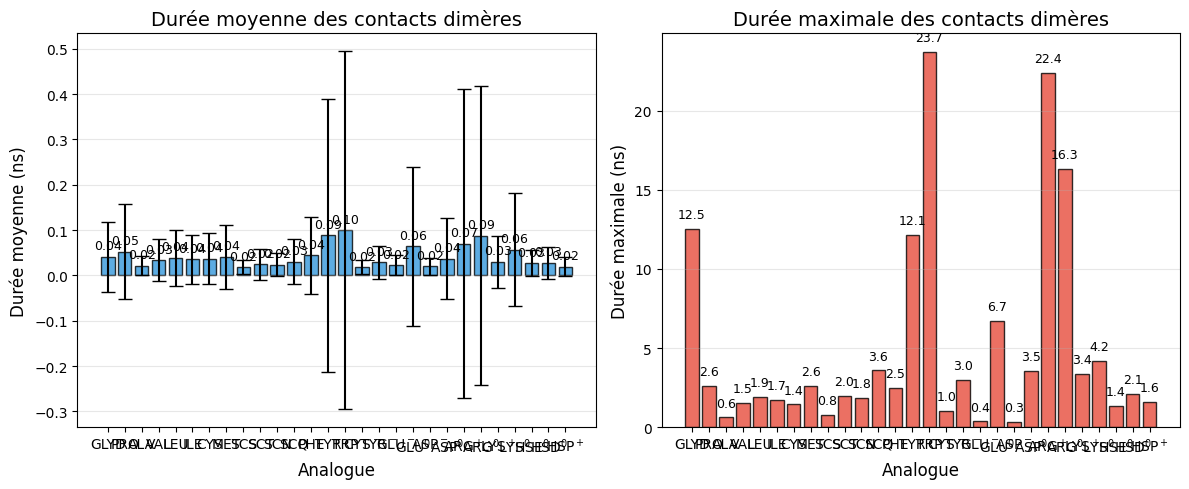


TABLEAU RÉCAPITULATIF DES DURÉES DE CONTACTS DIMÈRES
Analogue     N events    Moyenne (ns)    Médiane (ns)     Max (ns)   Max (µs)
----------------------------------------------------------------------------------------------------
GLYD          316,796           0.041           0.020         12.5      0.013
PRO           115,848           0.052           0.020          2.6      0.003
ALA           479,961           0.022           0.010          0.6      0.001
VAL           852,602           0.033           0.020          1.5      0.002
LEU           975,959           0.039           0.020          1.9      0.002
ILE         1,014,027           0.035           0.020          1.7      0.002
CYS           284,354           0.037           0.020          1.4      0.001
MET           708,040           0.041           0.020          2.6      0.003
SCS           161,967           0.018           0.010          0.8      0.001
SCT           149,943           0.025           0.020          2.

In [ ]:
# =============================================================================
# VISUALISATION DES DURÉES DE CONTACTS DIMÈRES
# =============================================================================

# Mapping des noms d'acides aminés
aa_names = {'GLYD': 'GLYD', 'SCP':'PRO', 'SCA':'ALA', 'SCV': 'VAL', 'SCL': 'LEU',
            'SCI': 'ILE', 'SCC': 'CYS', 'SCM': 'MET','SCF': 'PHE', 'SCY': 'TYR',
            'SCW': 'TRP', 'SCCM': 'CYS$^-$', 'SCYM': 'TYR$^-$', 'SCD': 'ASP$^-$',
            'SCDN': 'ASP$^0$', 'SCE': 'GLU$^-$', 'SCEN': 'GLU$^0$', 'SCR': 'ARG$^+$',
            'SCRN': 'ARG$^0$', 'SCK': 'LYS$^+$', 'SCKN': 'LYS$^0$', 'SCHE': 'HSE$^0$',
            'SCHD': 'HSD$^0$', 'SCHP': 'HSP$^+$'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1: Durée moyenne avec erreur standard
ax1 = axes[0]
x = np.arange(len(dimer_stats))
labels = [aa_names.get(sc, sc) for sc in dimer_stats['SC']]

bars = ax1.bar(x, dimer_stats['mean_ns'], yerr=dimer_stats['std_ps']/1000, 
               capsize=5, alpha=0.8, color='#3498db', edgecolor='black')
ax1.set_xlabel('Analogue', fontsize=12)
ax1.set_ylabel('Durée moyenne (ns)', fontsize=12)
ax1.set_title('Durée moyenne des contacts dimères', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, dimer_stats['mean_ns'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Graphique 2: Durée maximale
ax2 = axes[1]
bars2 = ax2.bar(x, dimer_stats['max_ns'], alpha=0.8, color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Analogue', fontsize=12)
ax2.set_ylabel('Durée maximale (ns)', fontsize=12)
ax2.set_title('Durée maximale des contacts dimères', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars2, dimer_stats['max_ns']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../plot/dimer_contact_durations.png', dpi=300, bbox_inches='tight')
plt.show()

# Tableau formaté
print("\n" + "=" * 100)
print("TABLEAU RÉCAPITULATIF DES DURÉES DE CONTACTS DIMÈRES")
print("=" * 100)
print(f"{'Analogue':<10} {'N events':>10} {'Moyenne (ns)':>15} {'Médiane (ns)':>15} {'Max (ns)':>12} {'Max (µs)':>10}")
print("-" * 100)
for _, row in dimer_stats.iterrows():
    name = aa_names.get(row['SC'], row['SC'])
    print(f"{name:<10} {row['n_events']:>10,} {row['mean_ns']:>15.3f} {row['median_ns']:>15.3f} {row['max_ns']:>12.1f} {row['max_ns']/1000:>10.3f}")
print("=" * 100)